# Лабораторная работа 3. Временные ряды

## Выполнила: Короткевич Анастасия Владимировна
## ИСУ: 466290


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

from scipy.signal import savgol_filter, periodogram
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.fft import fft, fftfreq
from statsmodels.tsa.stattools import acf

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)

ISU = 466290
VARIANT = sum(map(int, str(ISU))) % 60

print("Вариант:", VARIANT)

Вариант: 27


## Загрузка данных

In [80]:
DATA_PATH = "sell.csv"

def read_file(path):
    raw = pd.read_csv(path, encoding="cp1251", sep=";", header=None)
    return raw

raw = read_file(DATA_PATH)

start_col = 1 + (VARIANT - 1) * 6
cols = ["День"] + raw.iloc[1, start_col:start_col + 6].tolist()

df = raw.iloc[3:, [0] + list(range(start_col, start_col + 6))].copy()
df.columns = cols

for col in df.columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

df = df.dropna(how="all").reset_index(drop=True)
df["День"] = df["День"].astype(int)

display(df.head())

,День,мыло,порошок,средство,краска,пена,прибыль
0,1,126,13,23,45,19,28.926
1,2,117,17,28,41,24,28.619
2,3,90,20,19,40,19,25.973
3,4,71,15,20,46,19,25.705
4,5,126,30,21,43,19,29.792


## Задание 1. Реализация методов фильтрации

In [60]:
def exponential_smoothing(series, alpha=0.3):
    """Экспоненциальное сглаживание"""
    x = np.asarray(series, dtype=float)
    result = np.zeros_like(x)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha * x[i] + (1 - alpha) * result[i - 1]
    return result


def kalman_filter(series, process_var=1e-3, measurement_var=1.0):
    """Простой одномерный фильтр Калмана"""
    z = np.asarray(series, dtype=float)
    x_est = np.zeros_like(z)
    p_est = np.zeros_like(z)
    x_est[0] = z[0]
    p_est[0] = 1.0
    for k in range(1, len(z)):
        x_pred = x_est[k - 1]
        p_pred = p_est[k - 1] + process_var
        k_gain = p_pred / (p_pred + measurement_var)
        x_est[k] = x_pred + k_gain * (z[k] - x_pred)
        p_est[k] = (1 - k_gain) * p_pred
    return x_est


def savgol_smoothing(series, window_length=7, polyorder=2):
    """Фильтр Савицкого–Голея"""
    x = np.asarray(series, dtype=float)
    if window_length >= len(x):
        window_length = len(x) - 1
    if window_length % 2 == 0:
        window_length -= 1
    if window_length <= polyorder:
        window_length = polyorder + 3
        if window_length % 2 == 0:
            window_length += 1
    return savgol_filter(x, window_length=window_length, polyorder=polyorder)


def wavelet_denoising(series, wavelet="db4", level=2, threshold_scale=0.7):
    """Вейвлет преобразование"""
    x = np.asarray(series, dtype=float)
    coeffs = pywt.wavedec(x, wavelet, mode="periodization", level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_scale * sigma * np.sqrt(2 * np.log(len(x)))
    new_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        new_coeffs.append(pywt.threshold(c, threshold, mode="soft"))
    filtered = pywt.waverec(new_coeffs, wavelet, mode="periodization")
    return filtered[:len(x)]


def smoothing_score(original, filtered):
    original = np.asarray(original, dtype=float)
    filtered = np.asarray(filtered, dtype=float)

    return {
        "std_original_diff": np.std(np.diff(original)),
        "std_filtered_diff": np.std(np.diff(filtered)),
        "smooth_ratio": np.std(np.diff(filtered)) / np.std(np.diff(original)),
        "mae_to_original": mean_absolute_error(original, filtered),
        "rmse_to_original": np.sqrt(mean_squared_error(original, filtered))}

## Задание 2. Сравнение фильтров на данных продаж

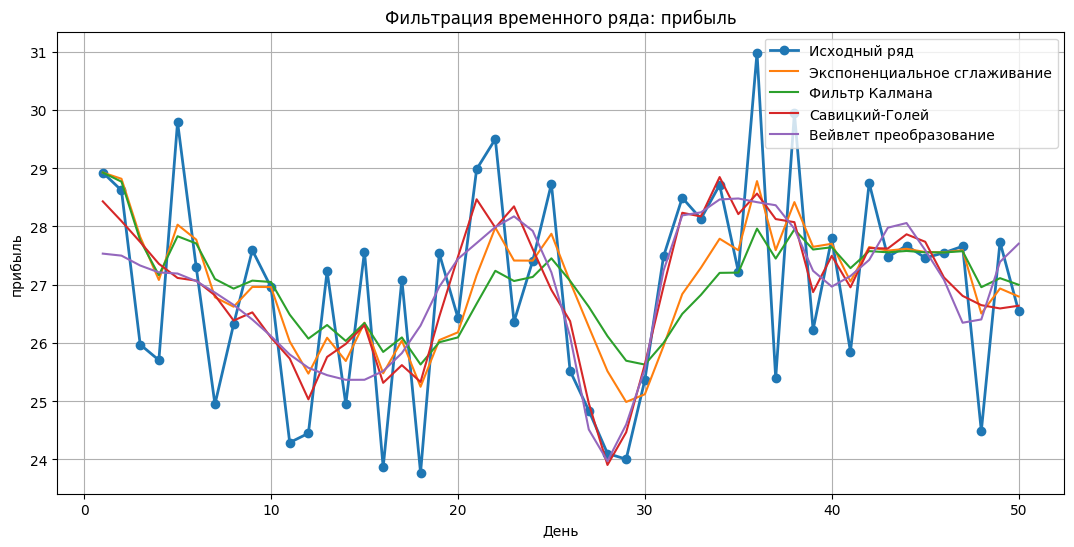

,Метод,std_original_diff,std_filtered_diff,smooth_ratio,mae_to_original,rmse_to_original
0,Экспоненциальное сглаживание,2.3743,0.6484,0.2731,0.9909,1.1948
1,Фильтр Калмана,2.3743,0.3947,0.1663,1.1693,1.4232
2,Савицкий-Голей,2.3743,0.6513,0.2743,0.9801,1.2192
3,Вейвлет преобразование,2.3743,0.5473,0.2305,1.1078,1.3289


In [61]:
target_col = "прибыль"
x = df[target_col].values

filtered = {
    "Экспоненциальное сглаживание": exponential_smoothing(x, alpha=0.35),
    "Фильтр Калмана": kalman_filter(x, process_var=0.05, measurement_var=1.0),
    "Савицкий-Голей": savgol_smoothing(x, window_length=7, polyorder=2),
    "Вейвлет преобразование": wavelet_denoising(x, wavelet="db4", level=2, threshold_scale=0.8)}

plt.figure(figsize=(13, 6))
plt.plot(df["День"], x, marker="o", label="Исходный ряд", linewidth=2)

for name, y in filtered.items():
    plt.plot(df["День"], y, label=name)

plt.title(f"Фильтрация временного ряда: {target_col}")
plt.xlabel("День")
plt.ylabel(target_col)
plt.legend()
plt.show()

rows = []
for name, y in filtered.items():
    row = {"Метод": name}
    row.update(smoothing_score(x, y))
    rows.append(row)

quality_table = pd.DataFrame(rows).round(4)
display(quality_table)

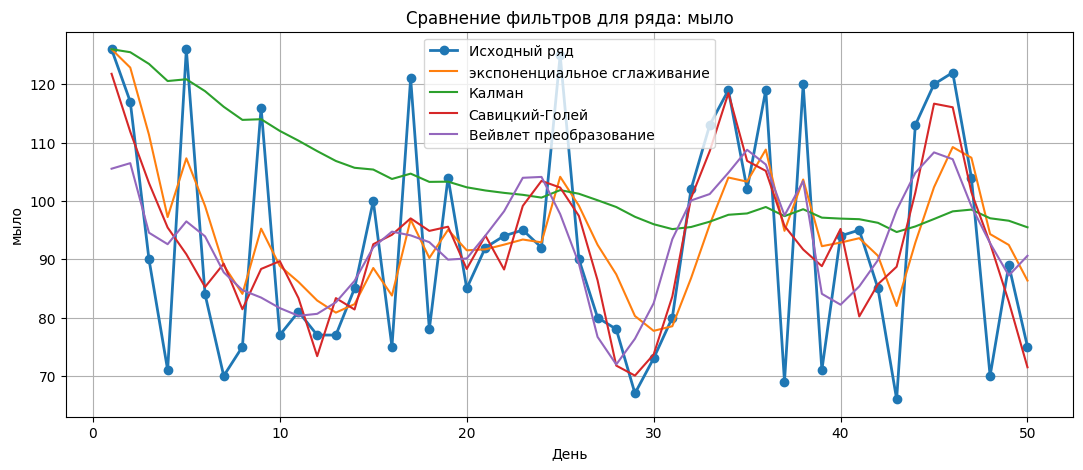

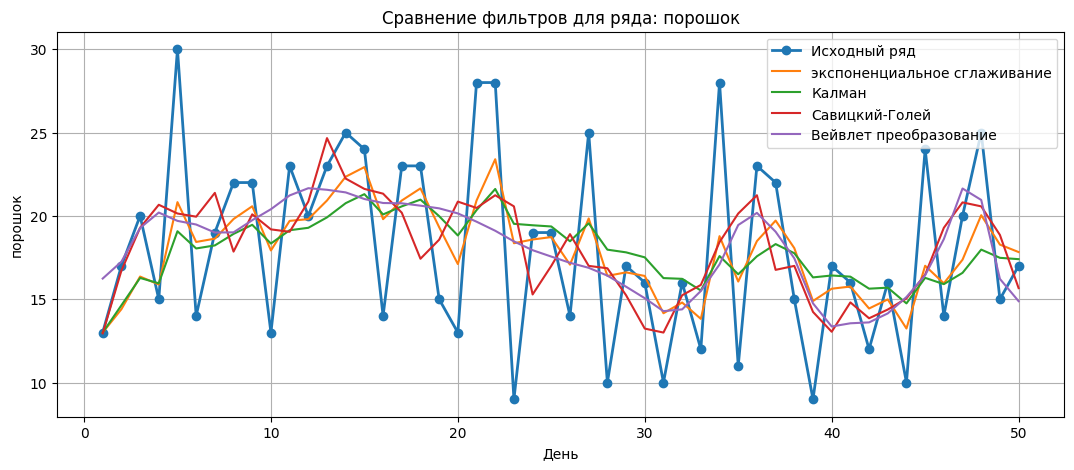

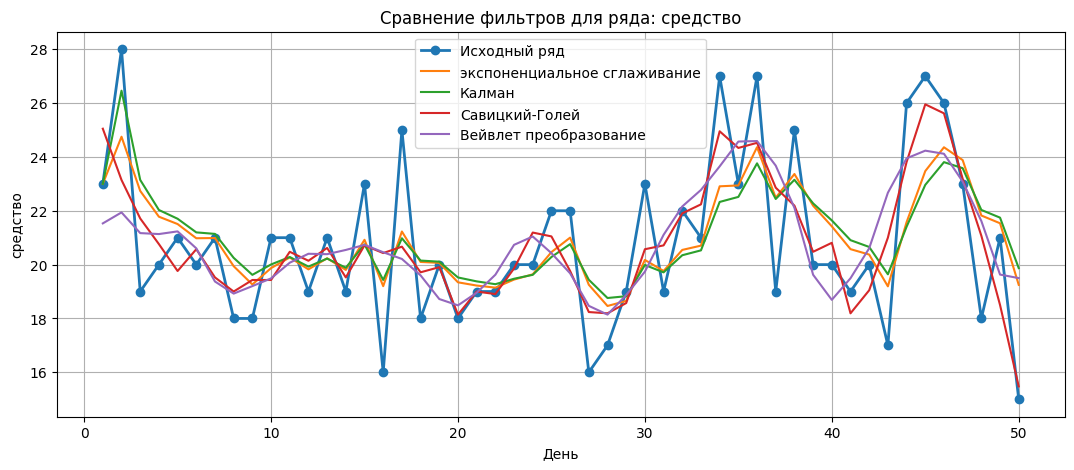

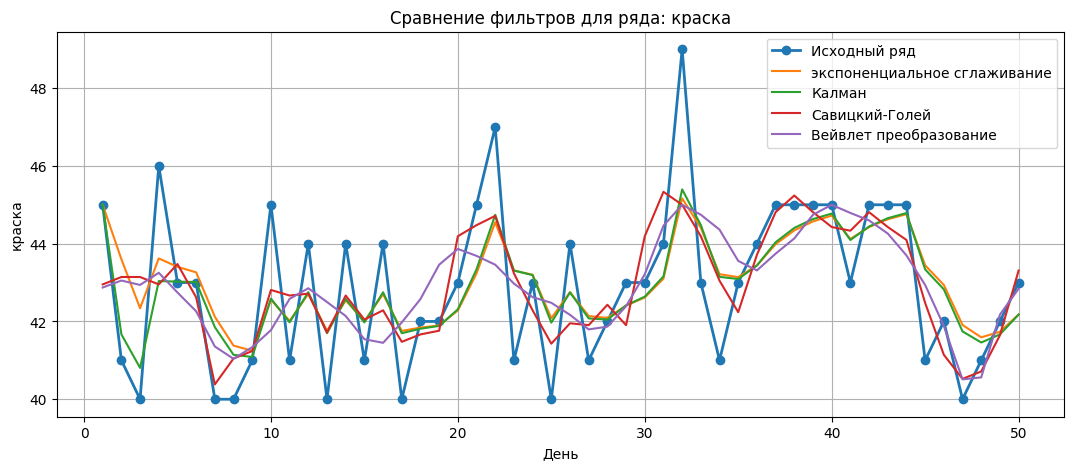

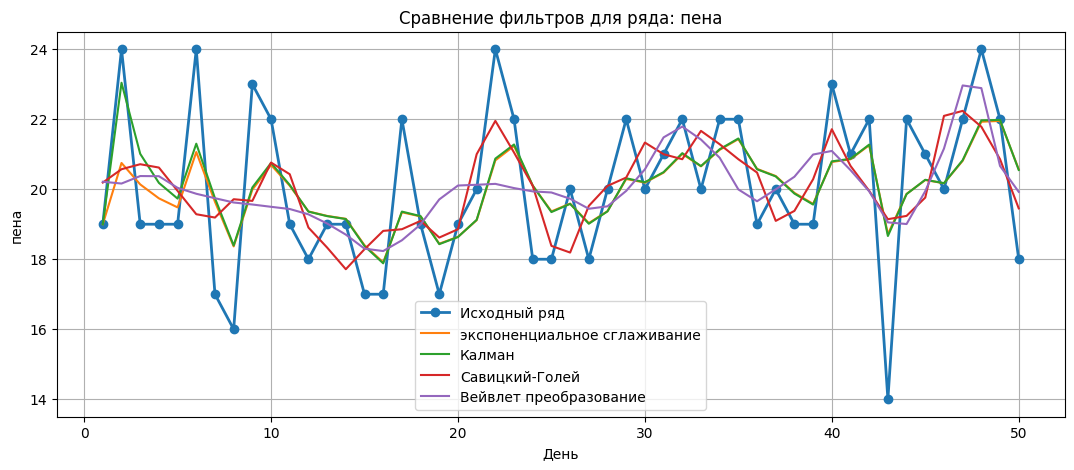

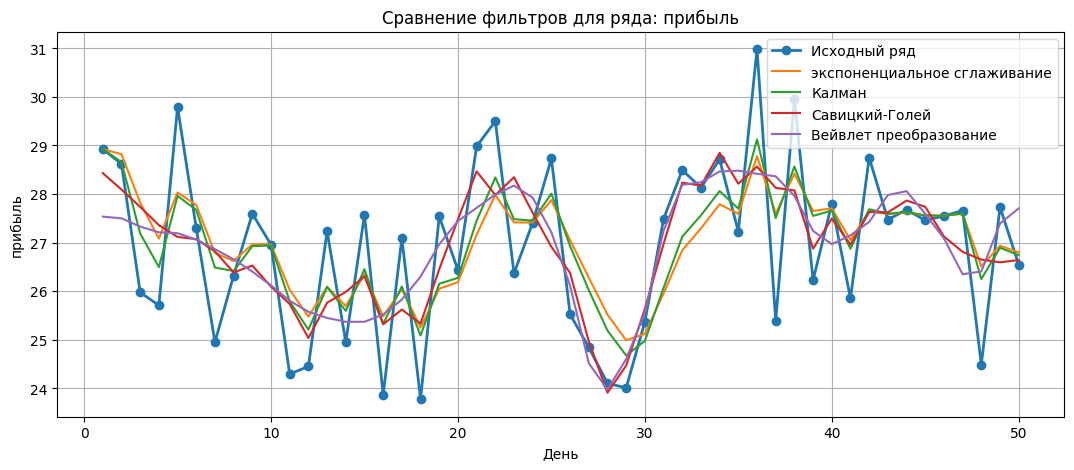

In [62]:
product_cols = [c for c in df.columns if c != "День"]

for col in product_cols:
    x_col = df[col].values

    filtered_col = {
        "экспоненциальное сглаживание": exponential_smoothing(x_col, alpha=0.35),
        "Калман": kalman_filter(x_col, process_var=0.05, measurement_var=np.var(x_col) * 0.05 + 1e-6),
        "Савицкий-Голей": savgol_smoothing(x_col, window_length=7, polyorder=2),
        "Вейвлет преобразование": wavelet_denoising(x_col, wavelet="db4", level=2, threshold_scale=0.8)}

    plt.figure(figsize=(13, 5))
    plt.plot(df["День"], x_col, marker="o", label="Исходный ряд", linewidth=2)
    for name, y in filtered_col.items():
        plt.plot(df["День"], y, label=name)

    plt.title(f"Сравнение фильтров для ряда: {col}")
    plt.xlabel("День")
    plt.ylabel(col)
    plt.legend()
    plt.show()

## Задание 3. Анализ данных

In [63]:
stats = df[product_cols].describe().T
stats["median"] = df[product_cols].median()
stats["range"] = df[product_cols].max() - df[product_cols].min()
stats = stats[["count", "mean", "median", "std", "min", "max", "range"]].round(3)
display(stats)

,count,mean,median,std,min,max,range
мыло,50.0,92.980,90.000,18.840,66.000,126.000,60.000
порошок,50.0,18.100,17.000,5.571,9.000,30.000,21.000
средство,50.0,20.820,20.000,3.088,15.000,28.000,13.000
краска,50.0,42.900,43.000,2.073,40.000,49.000,9.000
пена,50.0,20.060,20.000,2.253,14.000,24.000,10.000
прибыль,50.0,26.914,27.266,1.748,23.772,30.983,7.211


,мыло,порошок,средство,краска,пена,прибыль
мыло,1.000,0.126,0.702,-0.123,0.233,0.709
порошок,0.126,1.000,0.027,-0.264,-0.057,0.093
средство,0.702,0.027,1.000,-0.099,0.295,0.532
краска,-0.123,-0.264,-0.099,1.000,0.097,0.224
пена,0.233,-0.057,0.295,0.097,1.000,0.192
прибыль,0.709,0.093,0.532,0.224,0.192,1.000


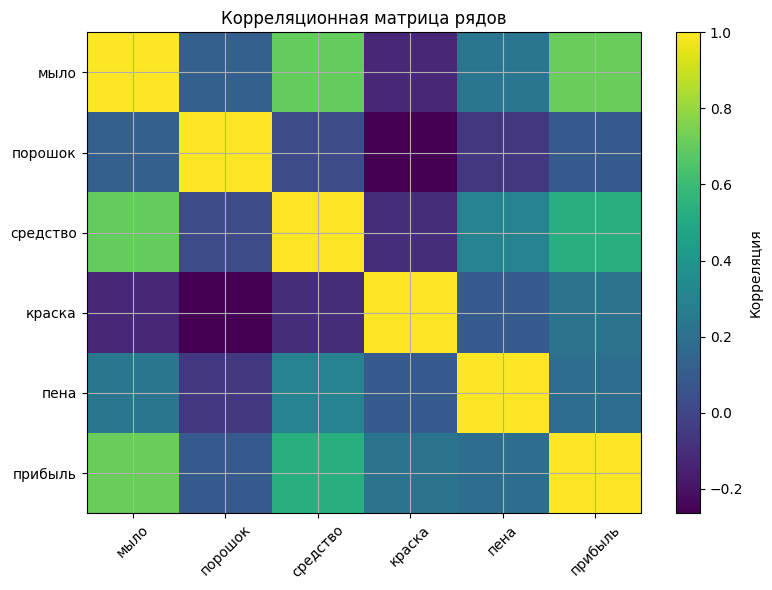

In [64]:
corr = df[product_cols].corr().round(3)
display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Корреляция")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Корреляционная матрица рядов")
plt.tight_layout()
plt.show()

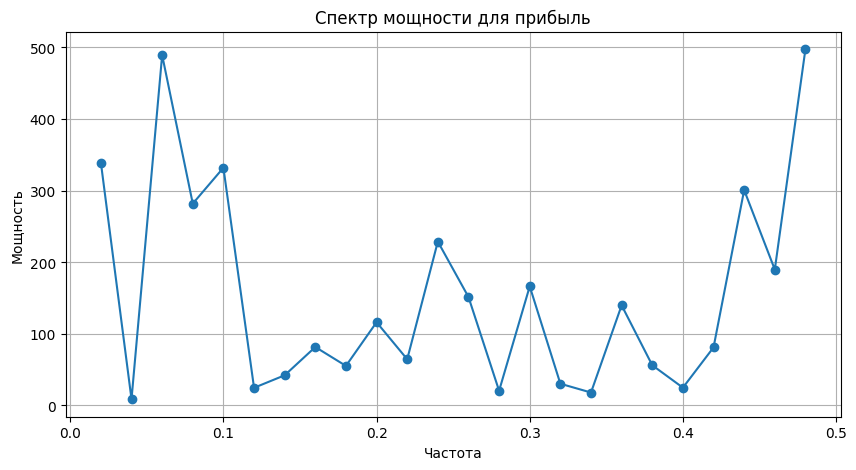

In [65]:
N = len(x)
yf = np.abs(fft(x - np.mean(x)))**2
xf = fftfreq(N, d=1)
mask = xf > 0

plt.figure(figsize=(10,5))
plt.plot(xf[mask], yf[mask], marker='o')
plt.title(f'Спектр мощности для {target_col}')
plt.xlabel('Частота')
plt.ylabel('Мощность')
plt.grid(True)
plt.show()

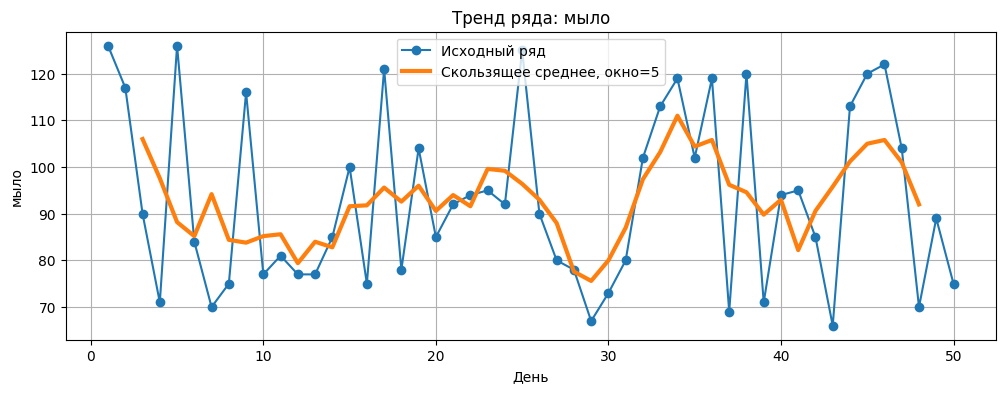

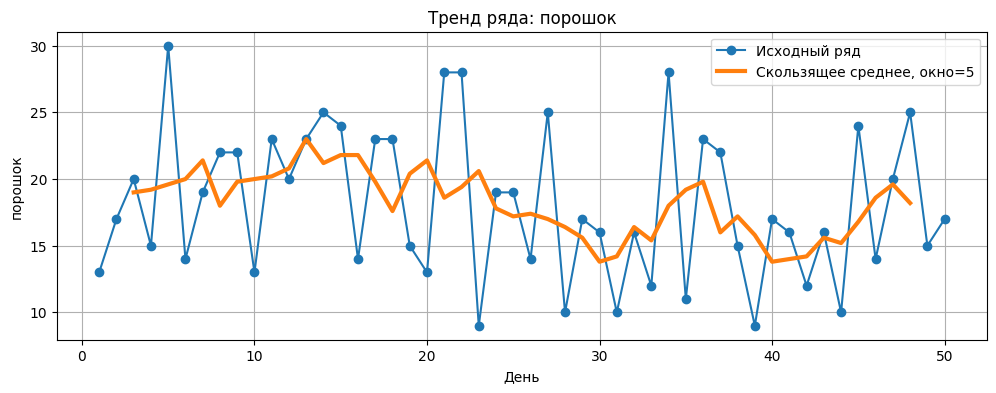

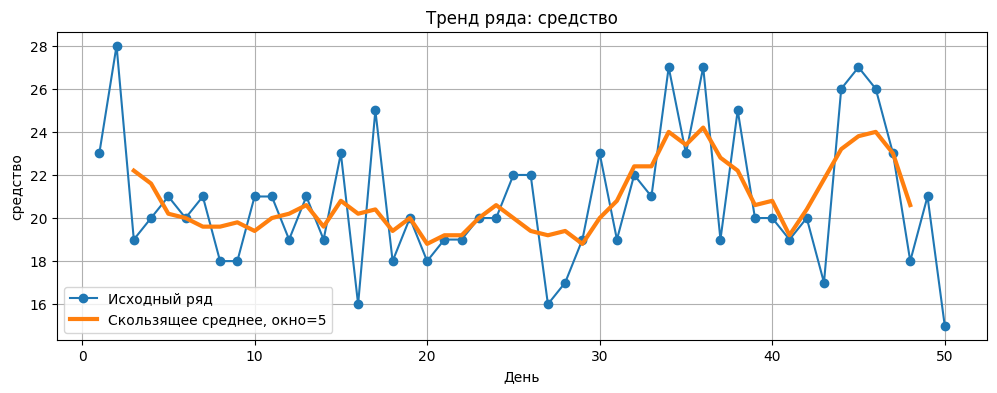

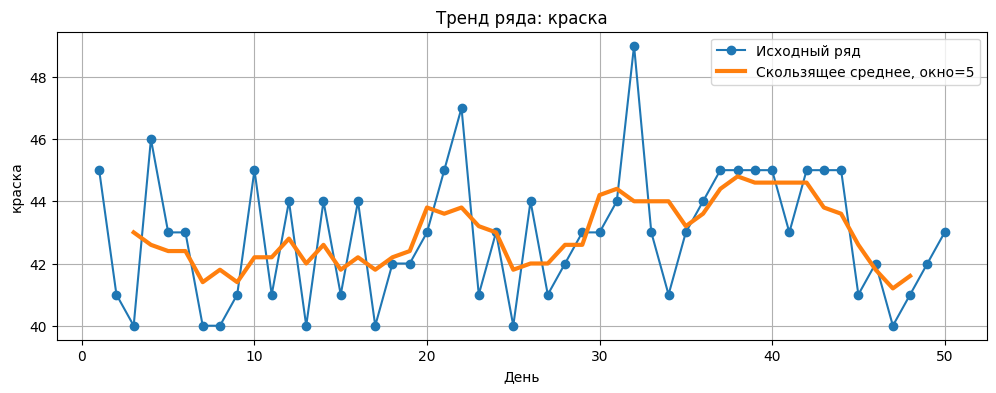

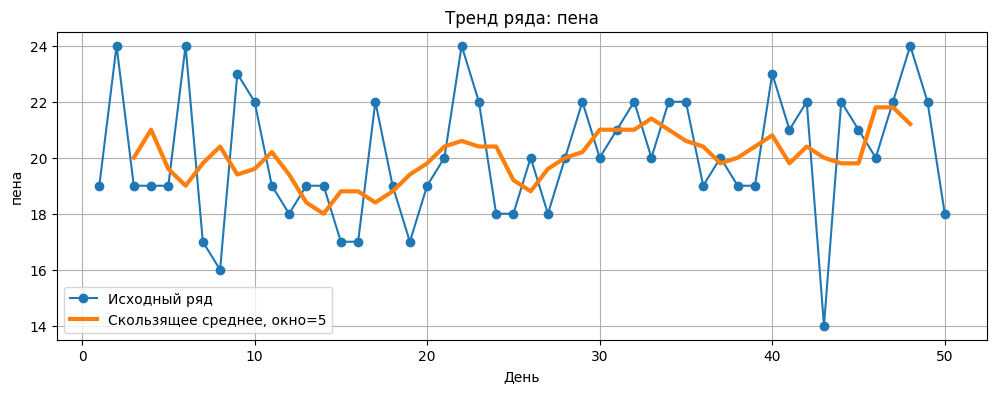

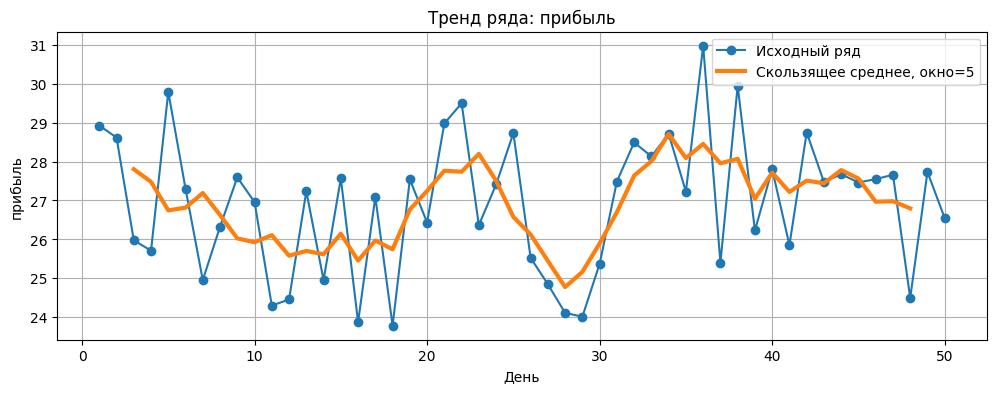

In [66]:
window = 5

for col in product_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df["День"], df[col], marker="o", label="Исходный ряд")
    plt.plot(df["День"], df[col].rolling(window=window, center=True).mean(), linewidth=3, label=f"Скользящее среднее, окно={window}")
    plt.title(f"Тренд ряда: {col}")
    plt.xlabel("День")
    plt.ylabel(col)
    plt.legend()
    plt.show()

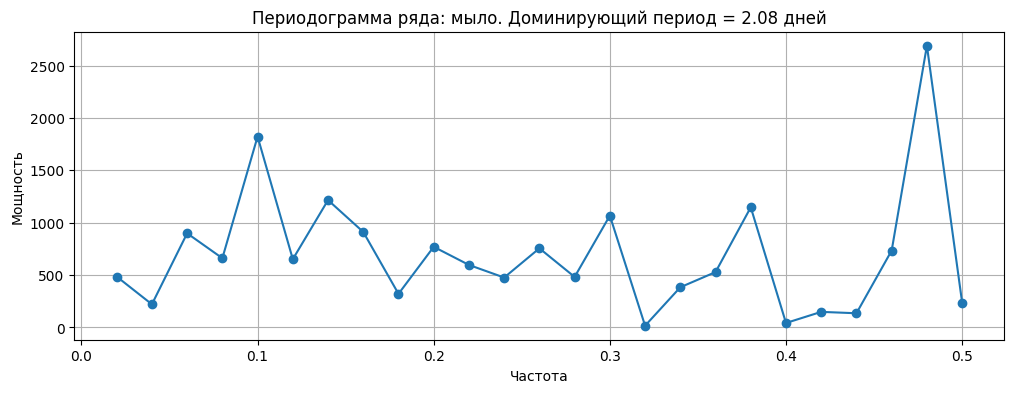

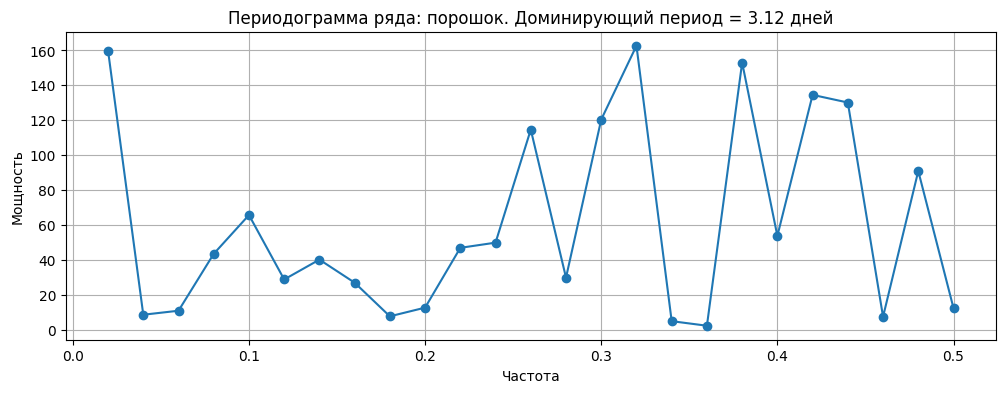

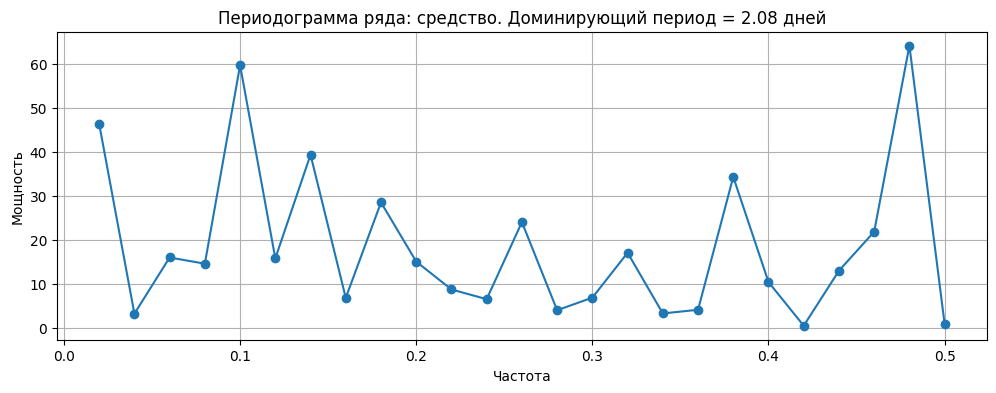

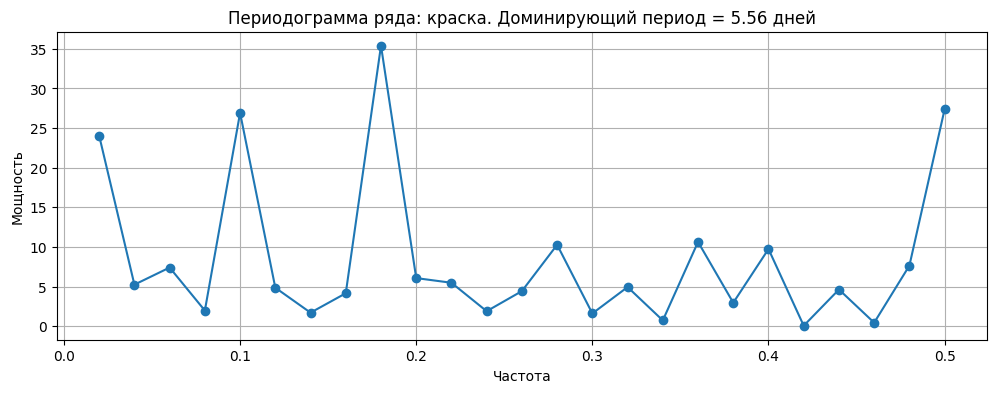

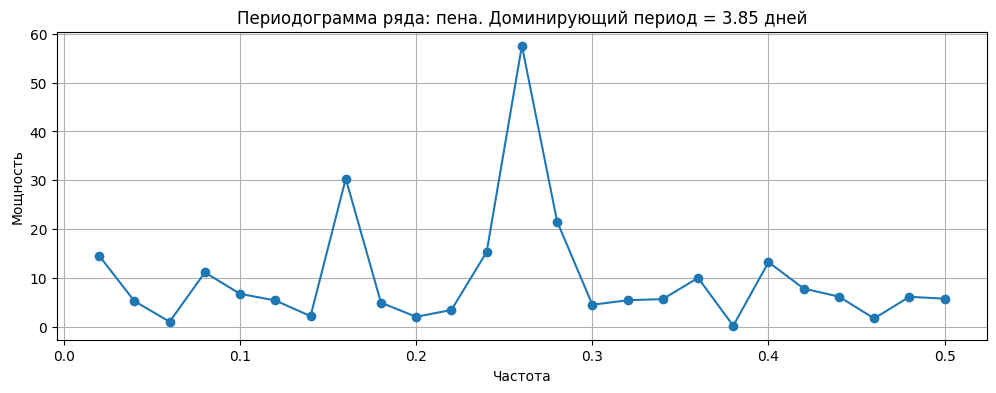

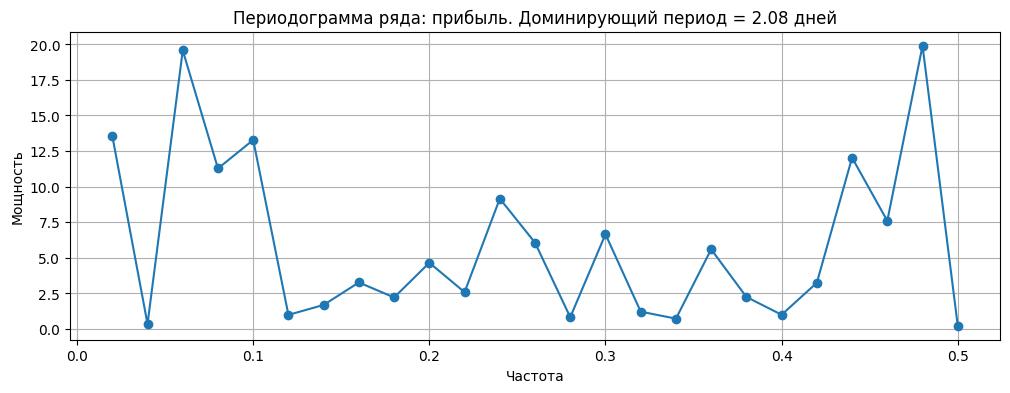

In [67]:
for col in product_cols:
    x_col = df[col].values
    x_centered = x_col - np.mean(x_col)

    freq, power = periodogram(x_centered)
    freq_nonzero = freq[1:]
    power_nonzero = power[1:]

    dominant_idx = np.argmax(power_nonzero)
    dominant_freq = freq_nonzero[dominant_idx]
    dominant_period = 1 / dominant_freq if dominant_freq != 0 else np.inf

    plt.figure(figsize=(12, 4))
    plt.plot(freq_nonzero, power_nonzero, marker="o")
    plt.title(f"Периодограмма ряда: {col}. Доминирующий период = {dominant_period:.2f} дней")
    plt.xlabel("Частота")
    plt.ylabel("Мощность")
    plt.show()

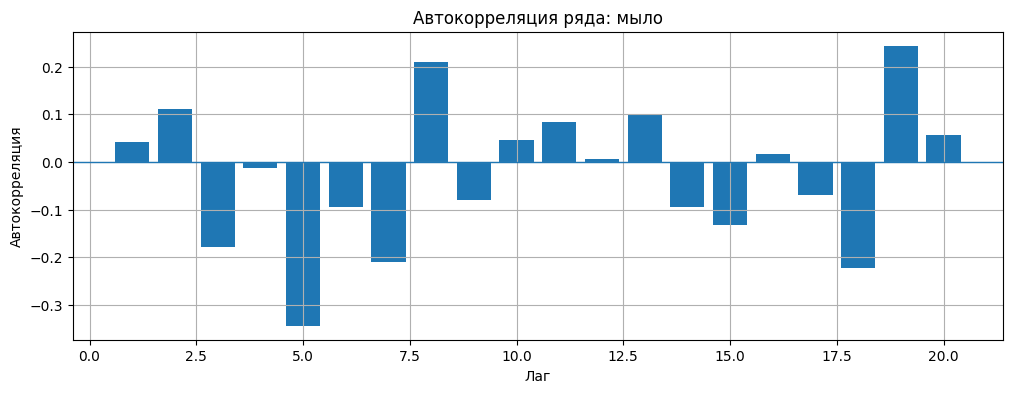

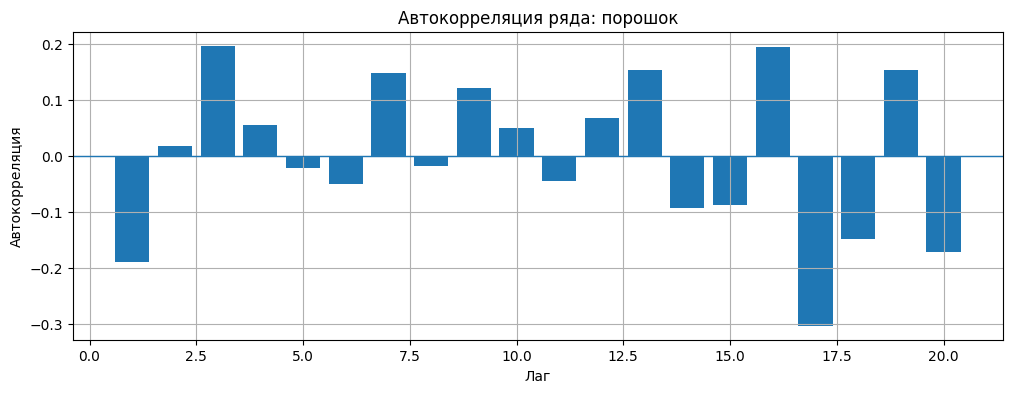

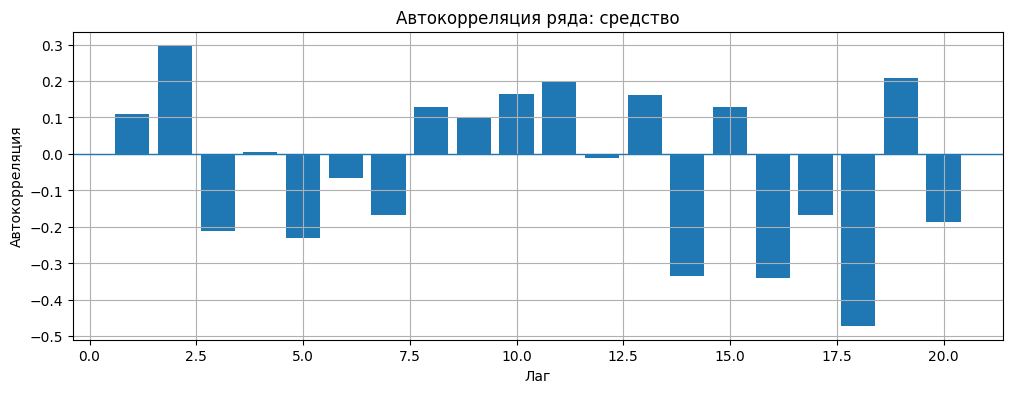

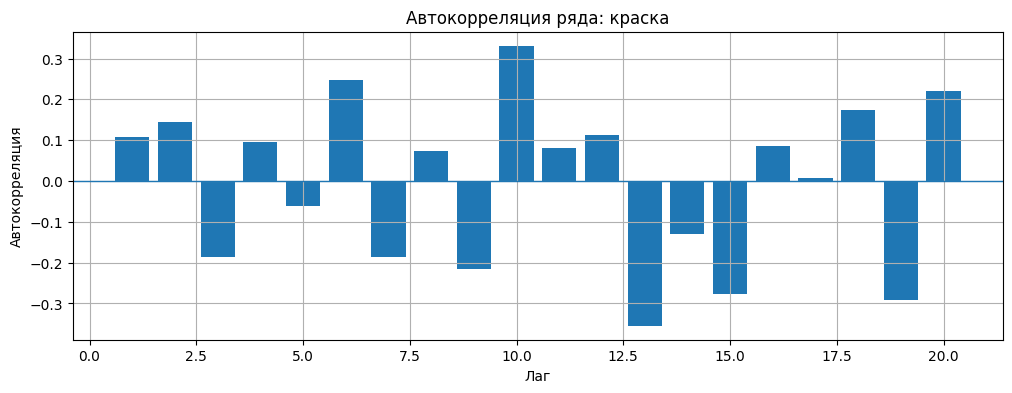

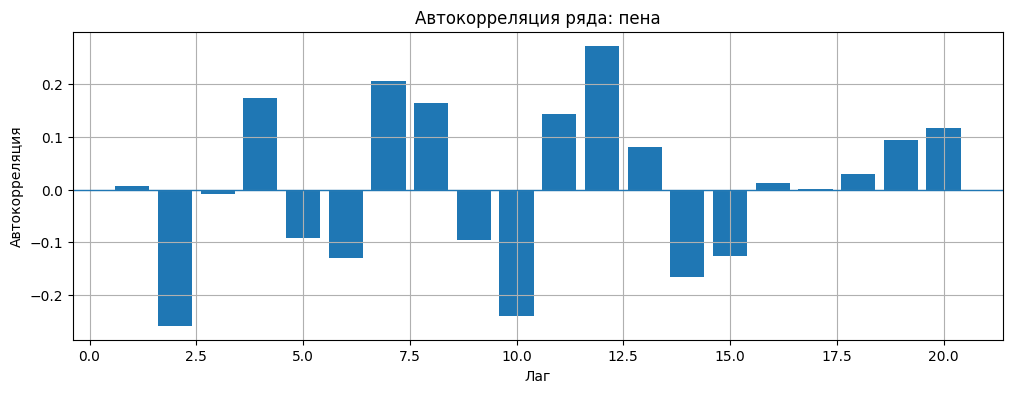

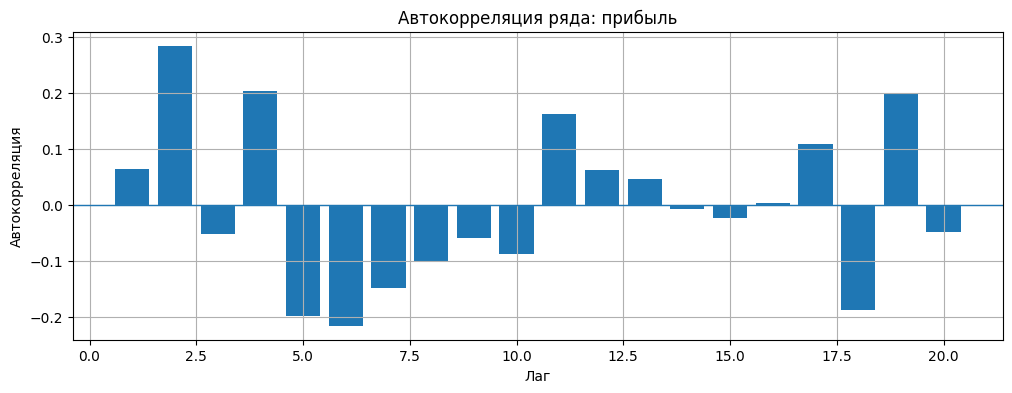

In [71]:
def autocorrelation(x, max_lag=20):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    result = []
    for lag in range(1, max_lag + 1):
        if lag >= len(x):
            result.append(np.nan)
        else:
            result.append(np.corrcoef(x[:-lag], x[lag:])[0, 1])
    return np.array(result)

max_lag = 20
lags = np.arange(1, max_lag + 1)

for col in product_cols:
    acfs = autocorrelation(df[col].values, max_lag=max_lag)

    plt.figure(figsize=(12, 4))
    plt.bar(lags, acfs)
    plt.axhline(0, linewidth=1)
    plt.title(f"Автокорреляция ряда: {col}")
    plt.xlabel("Лаг")
    plt.ylabel("Автокорреляция")
    plt.show()

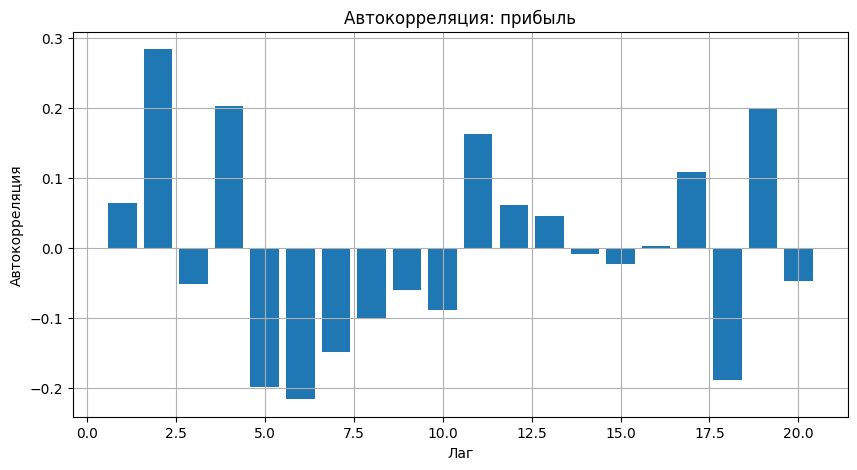

In [84]:
lags = 20
acf_values = autocorrelation(x, max_lag=lags)

plt.figure(figsize=(10, 5))
plt.bar(range(1, lags + 1), acf_values)

plt.title(f'Автокорреляция: {target_col}')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.grid(True)
plt.show()

## Задание 4. Hard-свобода: данные с двумя датчиками

In [75]:
import requests

def load_weather_data(latitude=59.9311, longitude=30.3609, start_date="2025-06-01", end_date="2025-06-14"):
    """Загрузка почасовых погодных данных: температура и влажность"""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {"latitude": latitude,"longitude": longitude,"start_date": start_date,
        "end_date": end_date,"hourly": "temperature_2m,relative_humidity_2m","timezone": "Europe/Moscow"}

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()["hourly"]

    weather = pd.DataFrame(data)
    weather["time"] = pd.to_datetime(weather["time"])
    return weather

weather = load_weather_data()
display(weather.head())
display(weather.describe().round(3))

,time,temperature_2m,relative_humidity_2m
0,2025-06-01 00:00:00,10.7,82
1,2025-06-01 01:00:00,10.6,82
2,2025-06-01 02:00:00,10.4,80
3,2025-06-01 03:00:00,9.9,79
4,2025-06-01 04:00:00,9.4,80


,time,temperature_2m,relative_humidity_2m
count,336,336.000,336.000
mean,2025-06-07 23:30:00,14.579,74.488
min,2025-06-01 00:00:00,8.000,45.000
25%,2025-06-04 11:45:00,12.400,63.000
50%,2025-06-07 23:30:00,14.700,75.000
75%,2025-06-11 11:15:00,16.600,87.000
max,2025-06-14 23:00:00,22.800,98.000
std,NaN,2.736,14.163


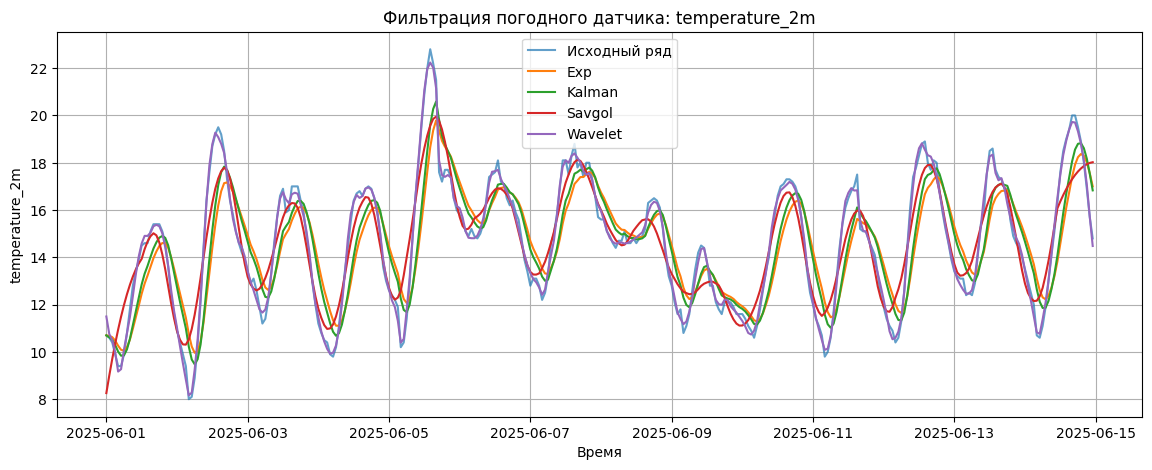

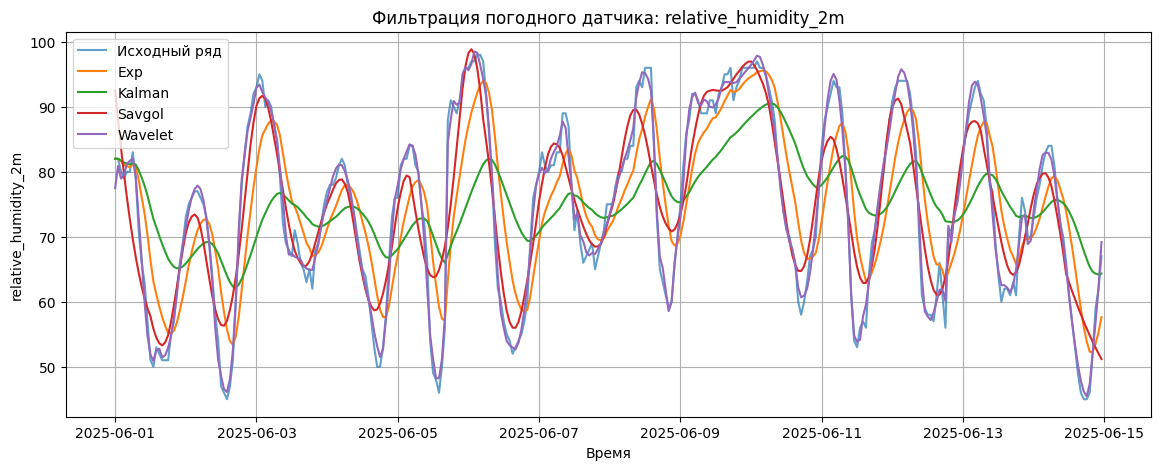

In [76]:
sensor_cols = ["temperature_2m", "relative_humidity_2m"]

for col in sensor_cols:
    x_sensor = weather[col].values

    weather[f"{col}_exp"] = exponential_smoothing(x_sensor, alpha=0.2)
    weather[f"{col}_kalman"] = kalman_filter(x_sensor,process_var=0.02,
        measurement_var=np.var(x_sensor) * 0.03 + 1e-6)
    weather[f"{col}_savgol"] = savgol_smoothing(x_sensor, window_length=25, polyorder=2)
    weather[f"{col}_wavelet"] = wavelet_denoising(x_sensor, wavelet="db4", level=3, threshold_scale=0.8)

    plt.figure(figsize=(14, 5))
    plt.plot(weather["time"], weather[col], label="Исходный ряд", alpha=0.7)
    plt.plot(weather["time"], weather[f"{col}_exp"], label="Exp")
    plt.plot(weather["time"], weather[f"{col}_kalman"], label="Kalman")
    plt.plot(weather["time"], weather[f"{col}_savgol"], label="Savgol")
    plt.plot(weather["time"], weather[f"{col}_wavelet"], label="Wavelet")

    plt.title(f"Фильтрация погодного датчика: {col}")
    plt.xlabel("Время")
    plt.ylabel(col)
    plt.legend()
    plt.show()

Корреляция между температурой и влажностью: -0.663


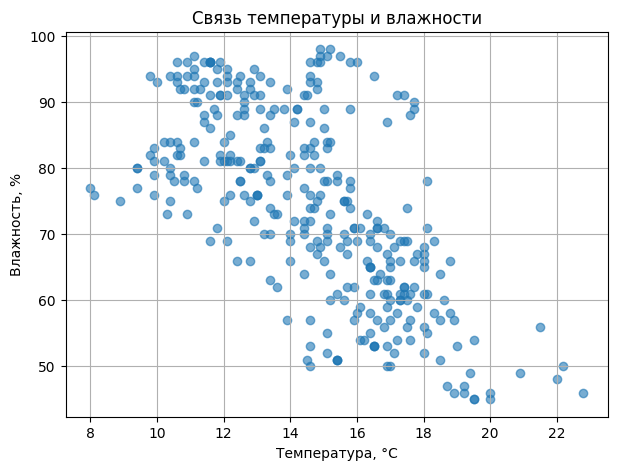

In [77]:
sensor_corr = weather[sensor_cols].corr().iloc[0, 1]
print(f"Корреляция между температурой и влажностью: {sensor_corr:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(weather["temperature_2m"], weather["relative_humidity_2m"], alpha=0.6)
plt.title("Связь температуры и влажности")
plt.xlabel("Температура, °C")
plt.ylabel("Влажность, %")
plt.show()

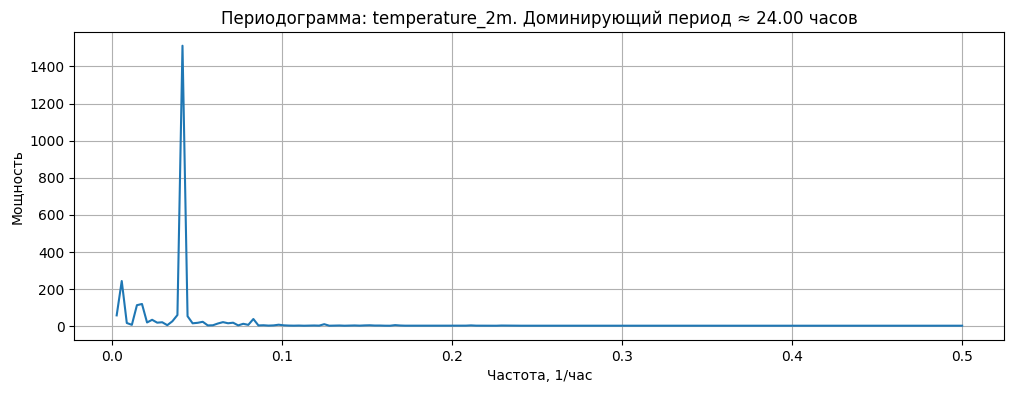

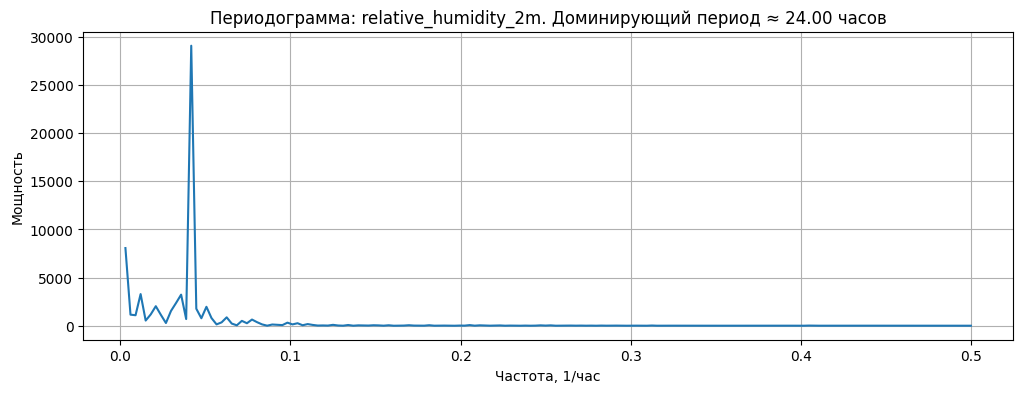

In [79]:
for col in sensor_cols:
    x_sensor = weather[col].values
    x_centered = x_sensor - np.mean(x_sensor)

    freq, power = periodogram(x_centered, fs=1)
    freq_nonzero = freq[1:]
    power_nonzero = power[1:]

    dominant_idx = np.argmax(power_nonzero)
    dominant_freq = freq_nonzero[dominant_idx]
    dominant_period_hours = 1 / dominant_freq if dominant_freq != 0 else np.inf

    plt.figure(figsize=(12, 4))
    plt.plot(freq_nonzero, power_nonzero)
    plt.title(f"Периодограмма: {col}. Доминирующий период = {dominant_period_hours:.2f} часов")
    plt.xlabel("Частота, 1/час")
    plt.ylabel("Мощность")
    plt.show()